In [1]:
from math import prod

classes = ['spam', 'ham']  # 클래스
prior = {'spam':0.4, 'ham':0.6}  # 사전확률 (c)
# 단어별 우도 P(X|C)
likelihood = {
    'spam':{'free':0.7, 'urgent':0.6},
    'ham':{'free':0.2, 'urgent':0.1}
}
X = ['free', 'urgent']

scores = {}

for c in classes:
    px_given_c = prod([likelihood[c][token] for token in X])
    scores[c] = px_given_c * prior[c]

pred = max(scores, key=scores.get)
print('NB scores:', scores)
print('NB prediction:', pred)

NB scores: {'spam': 0.168, 'ham': 0.012000000000000002}
NB prediction: spam


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

train_texts = ['free urgent offer', 'free free urgent', 'meeting schedule', 'project discussion']
labels = ['spam', 'spam', 'ham', 'ham']

vectorizer = CountVectorizer()
x_train = vectorizer.fit_transform(train_texts)
model = MultinomialNB()
model.fit(x_train, labels)
# 예측할 문장
text_text = ['i am free']
x_text = vectorizer.transform(text_text)
pred = model.predict(x_text)
pred


array(['spam'], dtype='<U4')

In [15]:
print('class prior p(c)')
print(model.class_log_prior_)

print('feature log probality p')
print(model.feature_log_prob_)

print('voca')
print(vectorizer.get_params)

class prior p(c)
[-0.69314718 -0.69314718]
feature log probality p
[[-1.70474809 -2.39789527 -1.70474809 -2.39789527 -1.70474809 -1.70474809
  -2.39789527]
 [-2.56494936 -1.178655   -2.56494936 -1.87180218 -2.56494936 -2.56494936
  -1.46633707]]
voca
<bound method BaseEstimator.get_params of CountVectorizer()>


In [ ]:
# iris 데이터로 품종 분류

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score

iris = load_iris(as_frame=True)
x = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=42)

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)
nb_pred = nb_model.predict(x_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, nb_pred))
nb_scores = cross_val_score(nb_model, x, y, cv=5)
nb_scores.mean()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



np.float64(0.9533333333333334)

In [35]:
from math import sqrt
from collections import Counter
import numpy as np

x_train = np.array([[1,1], [2,1], [4,4], [5,4]])
y_train = np.array([0, 0, 1, 1])
query = np.array([2, 2])
k = 3

def euclidean(p, q):
    return sqrt(sum((p - q)**2))

dists = [(euclidean(query, x), int(y)) for x, y in zip(x_train, y_train)]
dists.sort(key=lambda t: t[0])
knn = [label for _, label in dists[:k]]
pred = Counter(knn).most_common(1)[0][0]

print("k-NN sorted distances:", dists)
print("k-NN neighbors:", knn)
print("k-NN prediction:", pred)


k-NN sorted distances: [(1.0, 0), (1.4142135623730951, 0), (2.8284271247461903, 1), (3.605551275463989, 1)]
k-NN neighbors: [0, 0, 1]
k-NN prediction: 0


In [60]:
# iris 데이터로 품종 분류

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score

iris = load_iris(as_frame=True)
x = iris.data
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify=y, random_state=42)

from sklearn.neighbors import KNeighborsClassifier

kn_model = KNeighborsClassifier(n_neighbors=15)
kn_model.fit(x_train, y_train)
kn_pred = kn_model.predict(x_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, kn_pred))
kn_scores = cross_val_score(kn_model, x, y, cv=5)
kn_scores.mean()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



np.float64(0.9666666666666668)

In [56]:
# 최적의 k 찾기
# 교차검증을 통해서 (k = 1, 2, 3 ~ n)
# 각 값에 따른 교차검증(cv=5)을 해서 (score, k) 리스트로 저장
# score가 가장 높을때의 k 값을 출력

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
result = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, x, y, cv=cv)
    result.append((k, scores.mean()))

for k, score in result:
    print(f"k={k}, accuracy={score:.4f}")

# 최적 k 찾기
best_k, best_score = max(result, key=lambda x: x[1])
print("\n최적의 k:", best_k)
print("최고 정확도:", best_score)

k=1, accuracy=0.9533
k=2, accuracy=0.9467
k=3, accuracy=0.9533
k=4, accuracy=0.9667
k=5, accuracy=0.9667
k=6, accuracy=0.9600
k=7, accuracy=0.9600
k=8, accuracy=0.9533
k=9, accuracy=0.9600
k=10, accuracy=0.9600
k=11, accuracy=0.9733
k=12, accuracy=0.9667
k=13, accuracy=0.9733
k=14, accuracy=0.9733
k=15, accuracy=0.9800
k=16, accuracy=0.9667
k=17, accuracy=0.9800
k=18, accuracy=0.9733
k=19, accuracy=0.9733
k=20, accuracy=0.9533

최적의 k: 15
최고 정확도: 0.9800000000000001


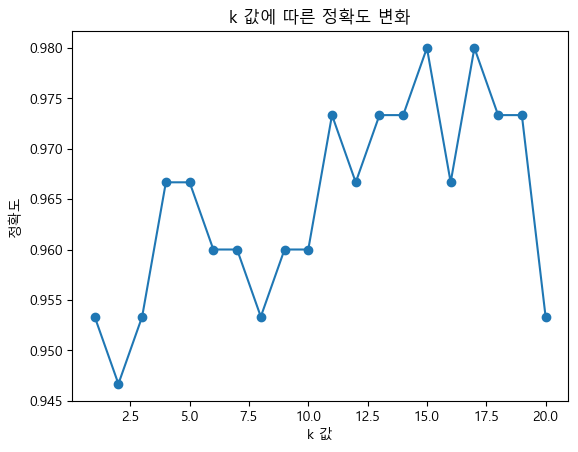

In [57]:
import warnings 
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# 한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

k_vals = [k for k, _ in result]
scores = [s for _, s in result]

plt.plot(k_vals, scores, marker='o')
plt.xlabel("k 값")
plt.ylabel("정확도")
plt.title("k 값에 따른 정확도 변화")
plt.show()

In [61]:
# 공통 데이터셋 — 이론 파트와 완전히 동일한 데이터
students = ["A", "B", "C", "D"]
study_hours      = [1,  3,  5,  2]   # 공부 시간
attendance_rate  = [0.4, 0.7, 0.9, 0.5]   # 출석률
score_true       = [28, 52, 74, 39]   # 실제 시험 점수
pass_true        = [0,  1,  1,  0]    # 합격(1) / 불합격(0)

print("=== 공통 데이터셋 ===")
for i, name in enumerate(students):
    print(f"  학생 {name}: study={study_hours[i]}h, "
          f"attendance={attendance_rate[i]}, "
          f"score={score_true[i]}, pass={pass_true[i]}")

=== 공통 데이터셋 ===
  학생 A: study=1h, attendance=0.4, score=28, pass=0
  학생 B: study=3h, attendance=0.7, score=52, pass=1
  학생 C: study=5h, attendance=0.9, score=74, pass=1
  학생 D: study=2h, attendance=0.5, score=39, pass=0


In [62]:
w = 12  # 가중차
b = 16  # 절편 : 기본 점수

def linear_predict(w, x, b):
    return w * x + b

predictions = []
for i, name in enumerate(students):
    y_hat = linear_predict(study_hours[i], w, b)
    predictions.append(y_hat)
    print(f"  학생 {name}: ŷ = 12x{study_hours[i]} + 16 = {y_hat:>5}  (실제: {score_true[i]})")

# 손계산 검증: A=28, B=52, C=76, D=40 이 나와야 합니다

  학생 A: ŷ = 12x1 + 16 =    28  (실제: 28)
  학생 B: ŷ = 12x3 + 16 =    52  (실제: 52)
  학생 C: ŷ = 12x5 + 16 =    76  (실제: 74)
  학생 D: ŷ = 12x2 + 16 =    40  (실제: 39)


In [63]:
import numpy as np

def calc_mse(y_true_list, y_pred_list):
    m = len(y_true_list)
    y_true_list = np.array(y_true_list)
    y_pred_list = np.array(y_pred_list)
    return sum((y_true_list - y_pred_list)**2) / m

for i, name in enumerate(students):
    err = score_true[i] - predictions[i]
    print(f"  학생 {name}: 오차={err:>3}, 제곱오차={err**2}")

mse = calc_mse(score_true, predictions)
print(f"\n  MSE = {mse}  ← 이론 2 손계산 결과와 동일해야 합니다 (기댓값: 1.25)")


  학생 A: 오차=  0, 제곱오차=0
  학생 B: 오차=  0, 제곱오차=0
  학생 C: 오차= -2, 제곱오차=4
  학생 D: 오차= -1, 제곱오차=1

  MSE = 1.25  ← 이론 2 손계산 결과와 동일해야 합니다 (기댓값: 1.25)


In [64]:
import math

def sigmoid(z):
    """
    시그모이드 함수: 임의의 실수 z를 0~1 사이로 변환
    σ(z) = 1 / (1 + e^(-z))
    """
    #### [ 빈칸: 이 부분을 완성하세요 — 시그모이드 수식 ]
    return 1 / (1 + math.exp(-z))

def logistic_score(study, attendance, w_study, w_att, bias):
    """
    로지스틱 회귀의 raw score 계산
    z = w_study * study + w_att * attendance + bias
    """
    #### [ 빈칸: 이 부분을 완성하세요 — z = wx + b ]
    return w_study * study + w_att * attendance + bias

# 이론 4에서 설정한 가중치
w_study = 2.0
w_att   = 1.5
bias    = -5.0

print("\n=== Step 4: 로지스틱 회귀 분류 ===")
print(f"  설정: w_study={w_study}, w_attendance={w_att}, bias={bias}")
print(f"  {'학생':^4} | {'z(raw score)':>12} | {'σ(z)':>8} | {'예측':^10} | {'실제':^6} | {'일치':^4}")
print("  " + "-" * 60)

all_correct = True
for i, name in enumerate(students):
    z = logistic_score(study_hours[i], attendance_rate[i], w_study, w_att, bias)
    prob = sigmoid(z)
    predicted = 1 if prob >= 0.5 else 0
    correct = "✓" if predicted == pass_true[i] else "✗"
    if predicted != pass_true[i]:
        all_correct = False
    label_pred = "합격(1)" if predicted == 1 else "불합격(0)"
    label_true = "합격(1)" if pass_true[i] == 1 else "불합격(0)"
    print(f"  학생 {name}  | {z:>12.4f} | {prob:>8.3f} | {label_pred:^10} | {label_true:^8} | {correct:^4}")

print(f"\n  결론: {'4명 전원 올바르게 분류됨 ✓' if all_correct else '일치하지 않는 샘플 있음 ✗'}")


=== Step 4: 로지스틱 회귀 분류 ===
  설정: w_study=2.0, w_attendance=1.5, bias=-5.0
   학생  | z(raw score) |     σ(z) |     예측     |   실제   |  일치 
  ------------------------------------------------------------
  학생 A  |      -2.4000 |    0.083 |   불합격(0)   |  불합격(0)  |  ✓  
  학생 B  |       2.0500 |    0.886 |   합격(1)    |  합격(1)   |  ✓  
  학생 C  |       6.3500 |    0.998 |   합격(1)    |  합격(1)   |  ✓  
  학생 D  |      -0.2500 |    0.438 |   불합격(0)   |  불합격(0)  |  ✓  

  결론: 4명 전원 올바르게 분류됨 ✓
